# Лабораторная работа №1 | Вариант 5

Выполнил Гига Максим М8О-313Б-23

### 1. Numpy

In [1]:
import numpy as np
from numpy.typing import NDArray
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

1. Создайте единичную матрицу размером 3х3

In [2]:
np.identity(3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

2. Создайте кастомный dtype который описывает цвет
состоящий из 4х unsigned bytes(RGBA пиксель)

In [3]:
np.dtype([("r", np.uint8), ("g", np.uint8), ("b", np.uint8), ("a", np.uint8)])

dtype([('r', 'u1'), ('g', 'u1'), ('b', 'u1'), ('a', 'u1')])

3. Как игнорировать все numpy warnings(не рекомендуем к использованию)?

In [4]:
# np.seterr(all="ignore")

4. Создайте случайный вектор размера 10 и отсортируйте его

In [5]:
arr = np.random.rand(10)
arr.sort()
arr                 # type:ignore

array([0.04438707, 0.04757441, 0.13211042, 0.30692301, 0.44182255,
       0.54624577, 0.59033027, 0.64930199, 0.78614644, 0.84619132])

5. Создайте read-only массив(неизменяемый)

In [6]:
read_only = np.zeros(10)
read_only.setflags(write=False)

6. Рассмотрим случайную матрицу размером 10х2,
представляющую декартовы координаты, преобразуем их в полярные
координаты

In [7]:
def cartesian_to_polar(xs: NDArray[np.float64]):
    x = xs[:, 0]
    y = xs[:, 1]
    rho = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    return np.stack((rho, phi), axis=1)


xy = np.random.random((10, 2))
cartesian_to_polar(xy)

array([[0.92684869, 0.57923482],
       [1.0925935 , 0.78039695],
       [0.86120591, 0.35906507],
       [0.88484584, 0.06218499],
       [0.70336497, 0.6795173 ],
       [1.18174302, 0.6342368 ],
       [0.66343772, 1.29812457],
       [1.0598472 , 1.14634524],
       [0.76944662, 0.02455944],
       [0.69435961, 0.71794383]])

7. Создайте структурированный массив с координатами x и y,
охватывающий область [0,1]x[0,1]

In [8]:
np.mgrid[0:1.01:0.01, 0:1.01:0.01].reshape(2, -1).T

array([[0.  , 0.  ],
       [0.  , 0.01],
       [0.  , 0.02],
       ...,
       [1.  , 0.98],
       [1.  , 0.99],
       [1.  , 1.  ]], shape=(10201, 2))

8. Учитывая два массива X и Y, постройте матрицу
Коши $C$ ($C_{ij} =\frac{1}{x_i - y_j}$)

In [9]:
x = np.random.normal(size=(5))
y = np.random.normal(size=(5))

print(x, y)
c = np.fromfunction(lambda i, j: 1/(x[i] + y[j]), shape=(5, 5), dtype=int)
c                   # type: ignore

[ 0.94243581 -0.90426739 -0.40485036 -0.50173859  0.10309729] [-1.12260352 -0.48556196 -0.2533223  -0.38548865  2.01572826]


array([[-5.55038411,  2.18878801,  1.45113973,  1.79550246,  0.33804751],
       [-0.49337133, -0.7195128 , -0.86386395, -0.77534043,  0.89971678],
       [-0.65468425, -1.1230752 , -1.51935815, -1.26527982,  0.62077952],
       [-0.61563386, -1.0128628 , -1.32439651, -1.12710697,  0.66050649],
       [-0.98086698, -2.61462058, -6.6566814 , -3.54118487,  0.47195957]])

9. Как конвертировать массив float(32 bit) к массиву целых чисел
(integer 32 bit) in place?

In [10]:
x = np.random.normal(scale=10, size=5)
x = x.astype(int)   # this converts values, result is the original rounded
x                   # type: ignore

array([ -4, -20,   4, -13,  13])

In [11]:
x = np.random.normal(scale=10, size=5)
x = x.view(int)     # this converts types
x                   # type: ignore

array([ 4620992216427783786,  4624356189821641840, -4602295808853620614,
        4623624153702186160, -4602283320141676332])

10. Как случайно заменить p элементов в 2D массиве?

In [12]:
def change_random(arr: NDArray, new_val, p: int):
    arr[np.random.choice(arr.size, p, replace=False)] = new_val


x = np.zeros(10)
change_random(x, 1, 4)
x               # type: ignore

array([0., 1., 0., 0., 0., 1., 0., 0., 1., 1.])

### 2. Pandas

Найдите ответы на вопросы или выполните действия с предложенным датасетом

Классический начальный набор данных - данные пассажиров титаника.

Файл: `data.csv`

```
PassangerId - уникальный номер пассажира
Survived - выжил человек или нет
Pclass - класс обслуживания
Name - имя человека, обращение к ней/нему
Sex - пол человека
Age - возраст на момент крушения
SibSp - количество братьев и сестер / супругов на борту "Титаника"
Parch - количество родителей / детей на борту "Титаника"
Ticket - номер билета
Fare - стоимость проезда для пассажиров
Cabin - каюта
Embarked - причал отбытия. C = Cherbourg Q = Queenstown S = Southampton
```

In [13]:
# Load dataset here
df = pd.read_csv("./data.csv")

1. Узнайте сколько было на борту человек

In [14]:
len(df)

891

2. Какой медианный и средний возраста пассажиров

In [15]:
print("медианный =", df["Age"].median())
print("средний =  ", df["Age"].mean())

медианный = 28.0
средний =   29.69911764705882


3. Посчитайте процент выживаемости детей(до 16 лет) и взрослых

In [16]:
ch = df[df["Age"] <= 16]
ad = df[df["Age"] > 16]
chs = ch[ch["Survived"] == 1]
ads = ad[ad["Survived"] == 1]
print(f"children: {len(chs)/len(ch) * 100}%")
print(f"adults:   {len(ads)/len(ad) * 100}%")

children: 55.00000000000001%
adults:   38.273615635179155%


4. Верна ли гипотеза, что женщины и дети сажались в шлюпки
первыми и выживали больше?

In [17]:
mask = (df["Age"] <= 16) | (df["Sex"] == 'female')
fc = df[mask]
mo = df[~mask]
print(f"woman and children: {len(fc[fc['Survived'] == 1]) / len(fc) * 100}%")
print(f"adult males:        {len(mo[mo['Survived'] == 1]) / len(mo) * 100}%")

woman and children: 69.86301369863014%
adult males:        16.53992395437262%


Гипотеза верна

5. Зависит ли выживаемость от класса обслуживания?

In [18]:
for cl in sorted(df['Pclass'].unique()):
    dfcl = df[df['Pclass'] == cl]
    print(f"{cl}: {len(dfcl[dfcl['Survived'] == 1]) / len(dfcl) * 100}%")

1: 62.96296296296296%
2: 47.28260869565217%
3: 24.236252545824847%


Да, зависит

6. Посчитайте средний возраст умерших женщин и мужчин

In [19]:
fema = df[(df["Sex"] == 'female') & (df['Survived'] == 0)]['Age'].mean()
male = df[(df["Sex"] == 'male') & (df['Survived'] == 0)]['Age'].mean()
print(f"female = {fema}, male = {male}")

female = 25.046875, male = 31.618055555555557


7. Различается ли процент выживаемости пассажиров с хотя бы
одним родственником на борту и одиночек?

In [20]:
rel = df[(df["SibSp"] > 0) | (df["Parch"] > 0)]
lon = df[(df["SibSp"] == 0) & (df["Parch"] == 0)]
print(f"with:    {len(rel[rel['Survived'] == 0])/len(rel)*100}%")
print(f"without: {len(lon[lon['Survived'] == 0])/len(lon)*100}%")

with:    49.43502824858757%
without: 69.6461824953445%


Различаются. Люди с родственниками имели меньший шанс выживания

8. Различается ли средняя стоимость билета у умерших и выживших пассажиров?

In [21]:
print(f"dead:  {df[df['Survived'] == 0]['Fare'].mean()}")
print(f"alive: {df[df['Survived'] == 1]['Fare'].mean()}")

dead:  22.117886885245902
alive: 48.39540760233918


Различается, пассажиры с более высокой ценой билета имели больший шанс выжить

9. Выведите максимальный и минимальный возраст выживших
пассажиров во 2 классе обслуживания

In [22]:
cl2 = df[df["Pclass"] == 2]["Age"]
print(f"max = {cl2.max()}, min = {cl2.min()}")

max = 70.0, min = 0.67


10. Подтвердите или опровергните гипотезу: молодым
мужчинам(от 18 лет) выжить легче, чем более взрослым

In [23]:
old_age_start = 30
mo = df[df["Sex"] == "male"]
my = mo[(mo["Age"] >= 18) & (mo["Age"] < old_age_start)]
mo = mo[mo["Age"] >= old_age_start]
print(f"young: {len(my[my['Survived'] == 1]) / len(my) * 100}%")
print(f"old:   {len(mo[mo['Survived'] == 1]) / len(mo) * 100}%")

young: 15.64245810055866%
old:   19.444444444444446%


Гипотеза верна

### 3. Визуализация

Используя библиотеки matplotlib/sns/plotly/pandas и набор данных
представленный ранее визуализируйте

1. Постройте гистограмму распределения возростов пассажиров

<Axes: ylabel='Frequency'>

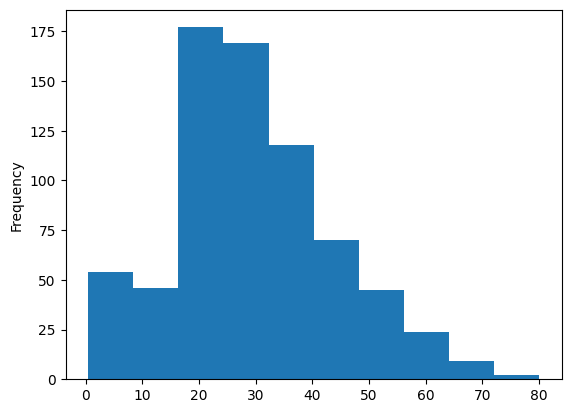

In [24]:
df["Age"].plot.hist()

2. Постройте гистограммы распределения цен для пассажиров разных классов

<Axes: xlabel='value', ylabel='Count'>

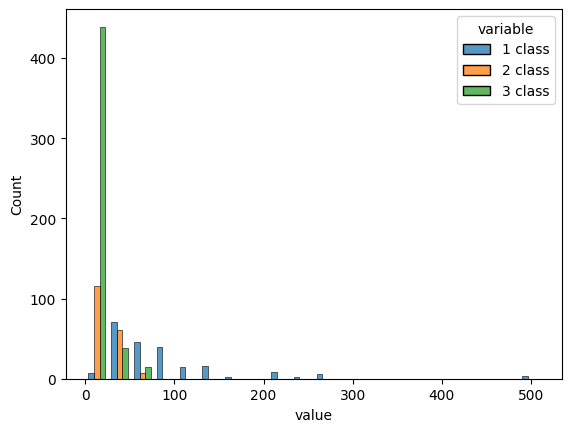

In [25]:
df2 = pd.DataFrame(
    {
        "1 class": df[df["Pclass"] == 1]["Fare"],
        "2 class": df[df["Pclass"] == 2]["Fare"],
        "3 class": df[df["Pclass"] == 3]["Fare"],
    }
)

sns.histplot(df2.melt(), x="value", hue="variable", multiple="dodge",
             shrink=0.75, bins=20)

3. Постройте зависимость цены от возраста пассажира

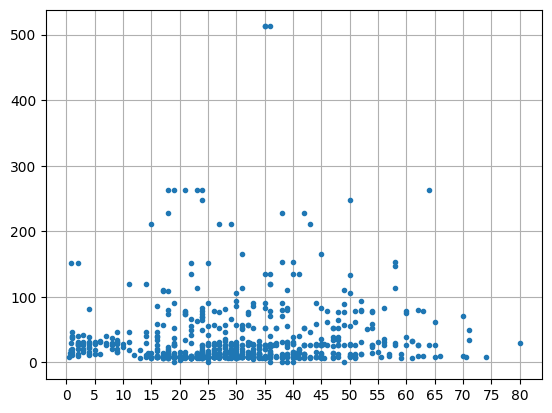

In [26]:
fig, ax = plt.subplots()
plt.plot(df["Age"], df["Fare"], "o", ms=3)
ax.xaxis.set_ticks(np.arange(0, df["Age"].max() + 1, 5))
plt.grid()
plt.show()

4. Постройте box plot отображающий распределение цен на билеты
в разных классах

<Axes: title={'center': 'Age box diagram'}, ylabel='fare'>

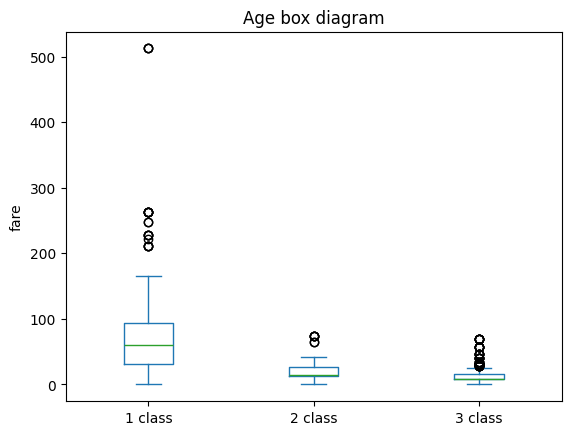

In [27]:
df2.plot.box(title="Age box diagram", ylabel="fare")

5. Визуализируйте распределение долей выживших среди мужчин,
женщин и детей(до 16 лет)

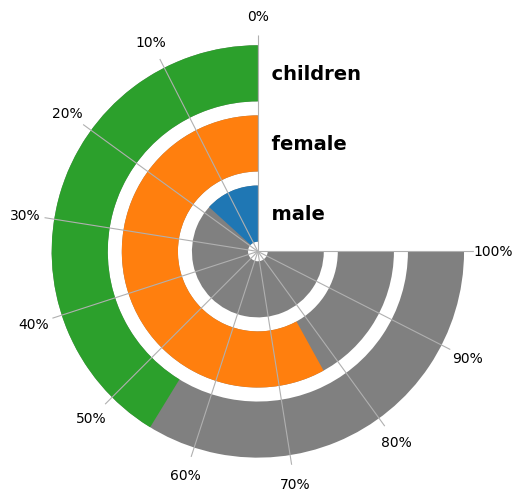

In [28]:
vars = [
    df[(df["Sex"] == "male") & (df["Age"] > 16)],
    df[(df["Sex"] == "female") & (df["Age"] > 16)],
    df[(df["Age"] <= 16)]
]
labels = ["male", "female", "children"]

fig = plt.figure()
rect = (0.1, 0.1, 0.9, 0.9)

ax.grid(False)
ax.tick_params(axis='both', left=False, bottom=False,
               labelbottom=False, labelleft=True)
ax = fig.add_axes(rect, polar=True, frameon=False)
ax.grid(False, axis="y")
ax.set_theta_direction(1)
ax.set_theta_zero_location('N')
ax.set_xticks(1.5*np.pi*np.linspace(0, 1, 11),
              labels=[f"{int(i * 100)}%" for i in np.linspace(0, 1, 11)])


ax.set_rgrids(range(len(vars)),
              labels=[f"  {i}" for i in labels],
              angle=0,
              fontsize=14, fontweight='bold',
              color='black', verticalalignment='center')

#

for i, v in enumerate(vars):
    ax.barh(i, 1*1.5*np.pi, color="gray")
    t = len(v[v["Survived"] == 1])/len(v)
    pos = t*1.5*np.pi
    ax.barh(i, pos)
plt.show()

6. Сравните плотности распределения возростов выживших и
умерших пассажиров, сделайте выводы

<Axes: ylabel='Density'>

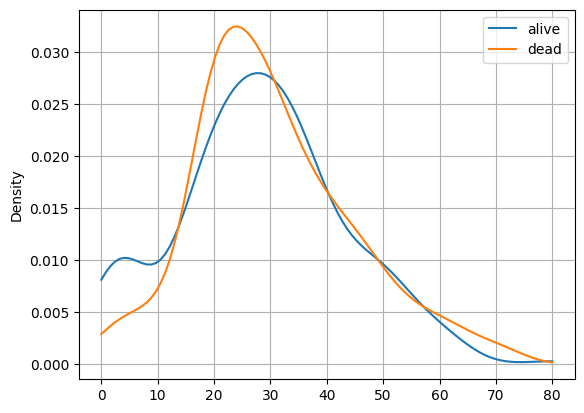

In [29]:
df2 = pd.DataFrame({
    "alive": df[df["Survived"] == 1]["Age"],
    "dead": df[df["Survived"] == 0]["Age"]
})
df2.plot.kde(ind=np.linspace(0, np.ceil(df["Age"].max()), 100), grid=True)

Пассажиры старше 30 лет не показывают значительной зависимости между
возрастом и процентом выживания. Отклонения плотностей - дети до 12 лет
процент выживаемости детей значительно выше
это также можно проследить в максимальных значения графика. Так как
количество детей составляет большую долю выживших, количество молодых
взрослых составляет
пропорционально меньшую долю

7. Постройте круговую диаграмму отображающую выживаемость мужчин и
женщин в разных классах обслуживания(визуализация должна быть
интуитивно понятная без объяснений, женщины и мужчины
соответствующих классов объеденены визуально в одну группу
и 2 подгруппы)*

\* Задание на доп. балл

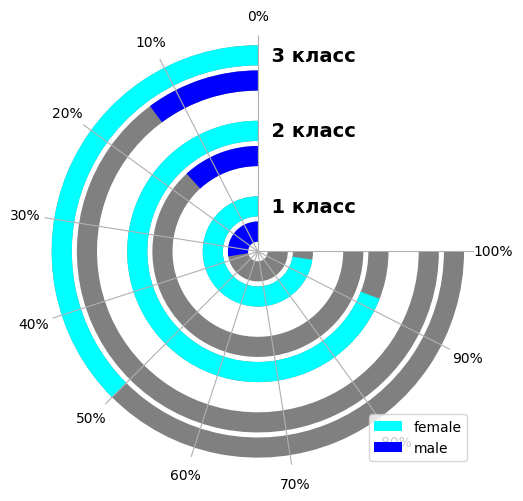

In [30]:
vars = [
    df[(df["Pclass"] == 1)],
    df[(df["Pclass"] == 2)],
    df[(df["Pclass"] == 3)],
]

fig = plt.figure()
rect = (0.1, 0.1, 0.9, 0.9)

ax.grid(False)
ax.tick_params(axis='both', left=False, bottom=False,
               labelbottom=False, labelleft=True)
ax = fig.add_axes(rect, polar=True, frameon=False)
ax.grid(False, axis="y")
ax.set_theta_direction(1)
ax.set_theta_zero_location('N')
ax.set_xticks(1.5*np.pi*np.linspace(0, 1, 11),
              labels=[f"{int(i * 100)}%" for i in np.linspace(0, 1, 11)])

ax.set_rgrids(range(9),
              labels=[f"  {i // 3 + 1} класс"
              if (i % 3) == 1 else "" for i in range(9)],
              angle=0,
              fontsize=14, fontweight='bold',
              color='black', verticalalignment='center')

for i, v in enumerate(vars):
    ax.barh(i*3, 1*1.5*np.pi, color="gray")
    ax.barh(i*3+1, 1*1.5*np.pi, color="gray")
    m = v[v["Sex"] == "male"]
    f = v[v["Sex"] == "female"]
    mp = len(m[m["Survived"] == 1])/len(m)
    fp = len(f[f["Survived"] == 1])/len(f)
    ax.barh(i*3, mp*1.5*np.pi, color="blue", label="male")
    ax.barh(i*3+1, fp*1.5*np.pi, color="cyan", label="female")
handles, labels = plt.gca().get_legend_handles_labels()
labels, ids = np.unique(labels, return_index=True)
handles = [handles[i] for i in ids]
plt.legend(handles, labels, loc="lower right")
plt.show()